# Ejercicio 5: Análisis de Redes Sociales

## Planteamiento del problema como búsqueda

Para este ejercicio, modelamos la identificación del **top influencer** como un problema de búsqueda en un grafo social.

1. **Espacio de configuraciones $\Omega$**
$\Omega = \{(m, v)\}$, donde:
- $m$ es una métrica de influencia en $\{\text{degree}, \text{betweenness}, \text{pagerank}\}$.
- $v$ es un nodo del grafo $G$.

2. **Tamaño de $\Omega$**
Si $|V| = n$ nodos y usamos 3 métricas, entonces:
$$|\Omega| = 3n$$
Para `karate_club_graph`, $n = 34$, por lo que $|\Omega| = 102$.

3. **Descripción de las configuraciones**
Cada configuración es un **par ordenado** $(m, v)$ (tipo: tupla/vector discreto) que representa evaluar al nodo $v$ con la métrica $m$.

4. **Métrica o función de costo a optimizar**
Queremos maximizar influencia. Definimos costo de minimización como:
$$C(m, v) = -\,I_m(v)$$
donde $I_m(v)$ es el puntaje de influencia del nodo $v$ bajo la métrica $m$.
Minimizar $C$ equivale a maximizar $I_m(v)$.

5. **Árbol de búsqueda (primeros 3 niveles)**
```text
Nivel 0: Raíz
  Inicio
    |
Nivel 1: Selección de métrica
  ├── degree
  ├── betweenness
  └── pagerank
    |
Nivel 2: Selección de nodo
  degree      -> (degree, 0), (degree, 1), (degree, 2), ...
  betweenness -> (betweenness, 0), (betweenness, 1), ...
  pagerank    -> (pagerank, 0), (pagerank, 1), ...
```

Con este planteamiento, el algoritmo recorre configuraciones y selecciona la de menor costo (o mayor influencia).

In [8]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# Configuración básica de estilo para gráficas
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['axes.grid'] = False

## (a) Cargar el grafo de red social predefinido

In [9]:
G = nx.karate_club_graph()
print(f'Grafo cargado correctamente: {G}')

Grafo cargado correctamente: Graph named "Zachary's Karate Club" with 34 nodes and 78 edges


## (b) Número de nodos, aristas y visualización

Número de nodos: 34
Número de aristas: 78


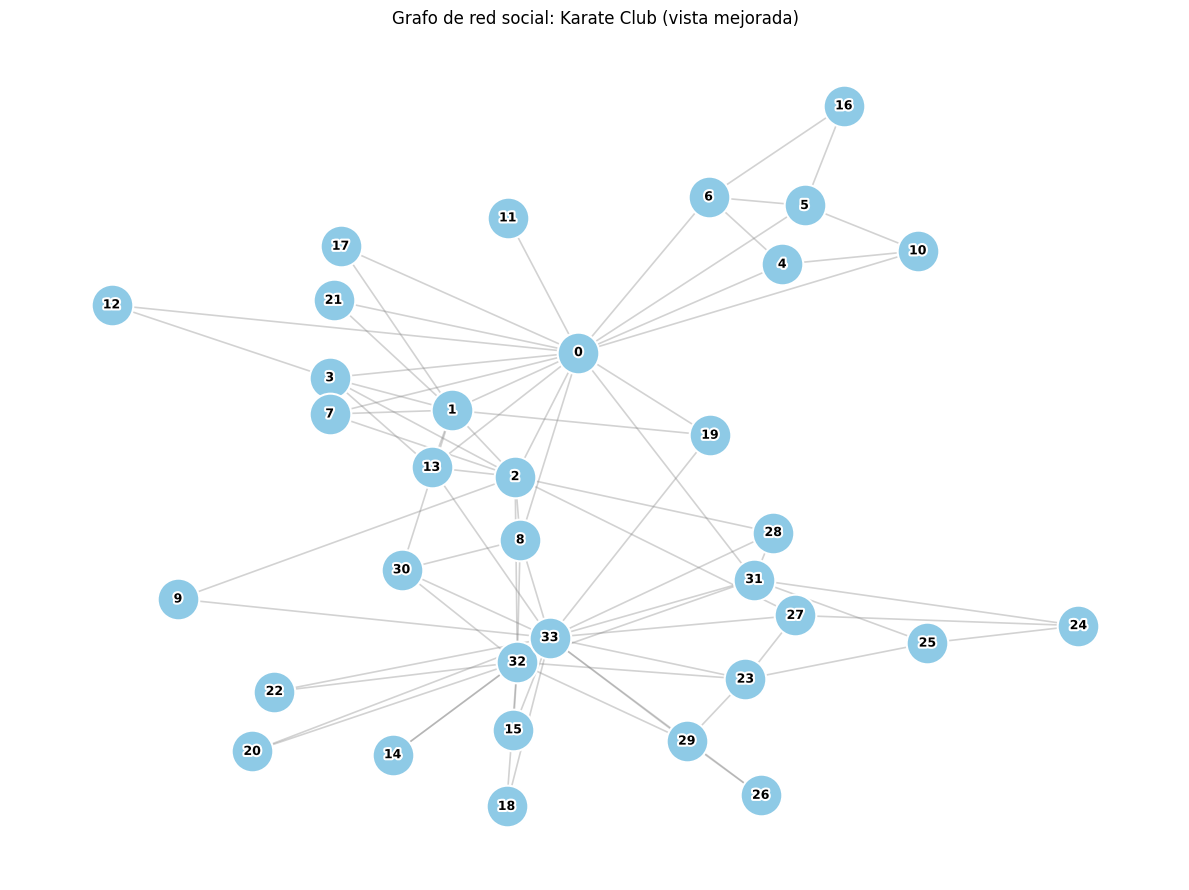

In [10]:
num_nodos = G.number_of_nodes()
num_aristas = G.number_of_edges()

print(f'Número de nodos: {num_nodos}')
print(f'Número de aristas: {num_aristas}')

# Layout más separado para mejorar legibilidad
pos = nx.spring_layout(G, seed=42, k=0.9, iterations=300)

plt.figure(figsize=(12, 9))
nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.35, width=1.2)
nx.draw_networkx_nodes(
    G, pos, node_color='#8ecae6', node_size=900, edgecolors='white', linewidths=1.5
)
labels = nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')

# Contorno blanco en etiquetas para que no se mezclen con las aristas
for txt in labels.values():
    txt.set_path_effects([pe.withStroke(linewidth=3, foreground='white')])

plt.title('Grafo de red social: Karate Club (vista mejorada)')
plt.axis('off')
plt.tight_layout()
plt.show()

## (c) Tres definiciones de influencer

Se proponen estas 3 métricas:
1. **Grado (degree centrality)**: un influencer tiene muchas conexiones directas.
2. **Intermediación (betweenness centrality)**: un influencer conecta rutas entre otros nodos.
3. **PageRank**: un influencer es importante según la estructura global de enlaces.

In [11]:
degree_c = nx.degree_centrality(G)
betweenness_c = nx.betweenness_centrality(G)
pagerank_c = nx.pagerank(G)

top_degree = max(degree_c, key=degree_c.get)
top_betweenness = max(betweenness_c, key=betweenness_c.get)
top_pagerank = max(pagerank_c, key=pagerank_c.get)

print('Top influencer por métrica:')
print(f'- Degree centrality: nodo {top_degree} (valor={degree_c[top_degree]:.4f})')
print(f'- Betweenness centrality: nodo {top_betweenness} (valor={betweenness_c[top_betweenness]:.4f})')
print(f'- PageRank: nodo {top_pagerank} (valor={pagerank_c[top_pagerank]:.4f})')

Top influencer por métrica:
- Degree centrality: nodo 33 (valor=0.5152)
- Betweenness centrality: nodo 0 (valor=0.4376)
- PageRank: nodo 33 (valor=0.0970)


## (d) Gráficas destacando el top influencer de cada propuesta

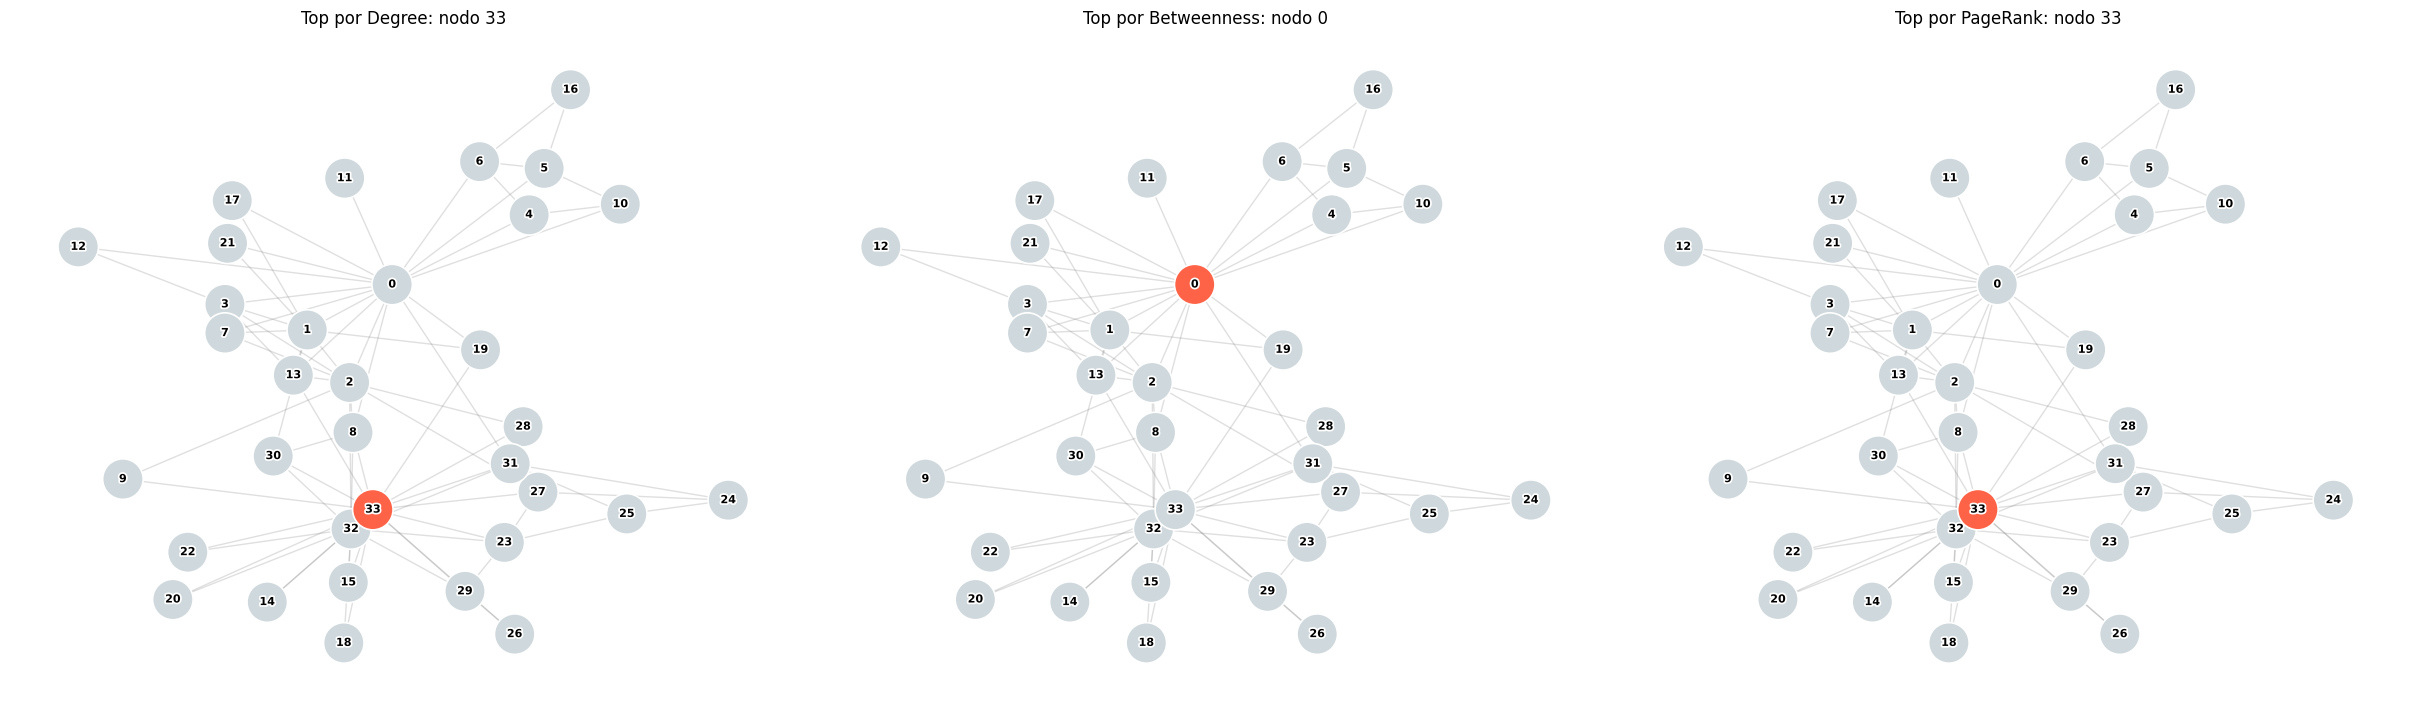

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7), constrained_layout=True)

casos = [
    ('Top por Degree', top_degree),
    ('Top por Betweenness', top_betweenness),
    ('Top por PageRank', top_pagerank),
]

for ax, (titulo, top_node) in zip(axes, casos):
    colores = ['tomato' if n == top_node else '#cfd8dc' for n in G.nodes()]
    nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.25, width=1.0, ax=ax)
    nx.draw_networkx_nodes(
        G, pos, node_color=colores, node_size=850, edgecolors='white', linewidths=1.2, ax=ax
    )
    labels = nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold', ax=ax)
    for txt in labels.values():
        txt.set_path_effects([pe.withStroke(linewidth=2.5, foreground='white')])
    ax.set_title(f'{titulo}: nodo {top_node}')
    ax.axis('off')

plt.show()

## (e) Identificación de comunidades

Primero intentamos Louvain (si está disponible en la versión de `networkx` instalada).
Si no, usamos partición codiciosa (`greedy_modularity_communities`).

Luego clasificamos comunidades de tamaño 3, 4 y 5 o más.

In [13]:
# Intentar Louvain con fallback a greedy
metodo = ''
try:
    from networkx.algorithms.community import louvain_communities
    comunidades = louvain_communities(G, seed=42)
    metodo = 'Louvain'
except Exception:
    from networkx.algorithms.community import greedy_modularity_communities
    comunidades = list(greedy_modularity_communities(G))
    metodo = 'Greedy modularity'

print(f'Método usado: {metodo}')
print(f'Número total de comunidades: {len(comunidades)}')

# Clasificación por tamaño
com_3 = [c for c in comunidades if len(c) == 3]
com_4 = [c for c in comunidades if len(c) == 4]
com_5_mas = [c for c in comunidades if len(c) >= 5]

print(f'Comunidades tamaño 3: {len(com_3)}')
print(f'Comunidades tamaño 4: {len(com_4)}')
print(f'Comunidades tamaño 5 o más: {len(com_5_mas)}')

def mostrar_comunidades(lista, etiqueta):
    print(f'\n{etiqueta}')
    if not lista:
        print('  Ninguna')
        return
    for i, c in enumerate(lista, 1):
        print(f'  {i}: {sorted(c)}')

mostrar_comunidades(com_3, 'Detalle comunidades de tamaño 3:')
mostrar_comunidades(com_4, 'Detalle comunidades de tamaño 4:')
mostrar_comunidades(com_5_mas, 'Detalle comunidades de tamaño 5 o más:')

Método usado: Louvain
Número total de comunidades: 4
Comunidades tamaño 3: 0
Comunidades tamaño 4: 1
Comunidades tamaño 5 o más: 3

Detalle comunidades de tamaño 3:
  Ninguna

Detalle comunidades de tamaño 4:
  1: [24, 25, 28, 31]

Detalle comunidades de tamaño 5 o más:
  1: [1, 2, 3, 7, 12, 13]
  2: [0, 4, 5, 6, 10, 11, 16, 17, 19, 21]
  3: [8, 9, 14, 15, 18, 20, 22, 23, 26, 27, 29, 30, 32, 33]


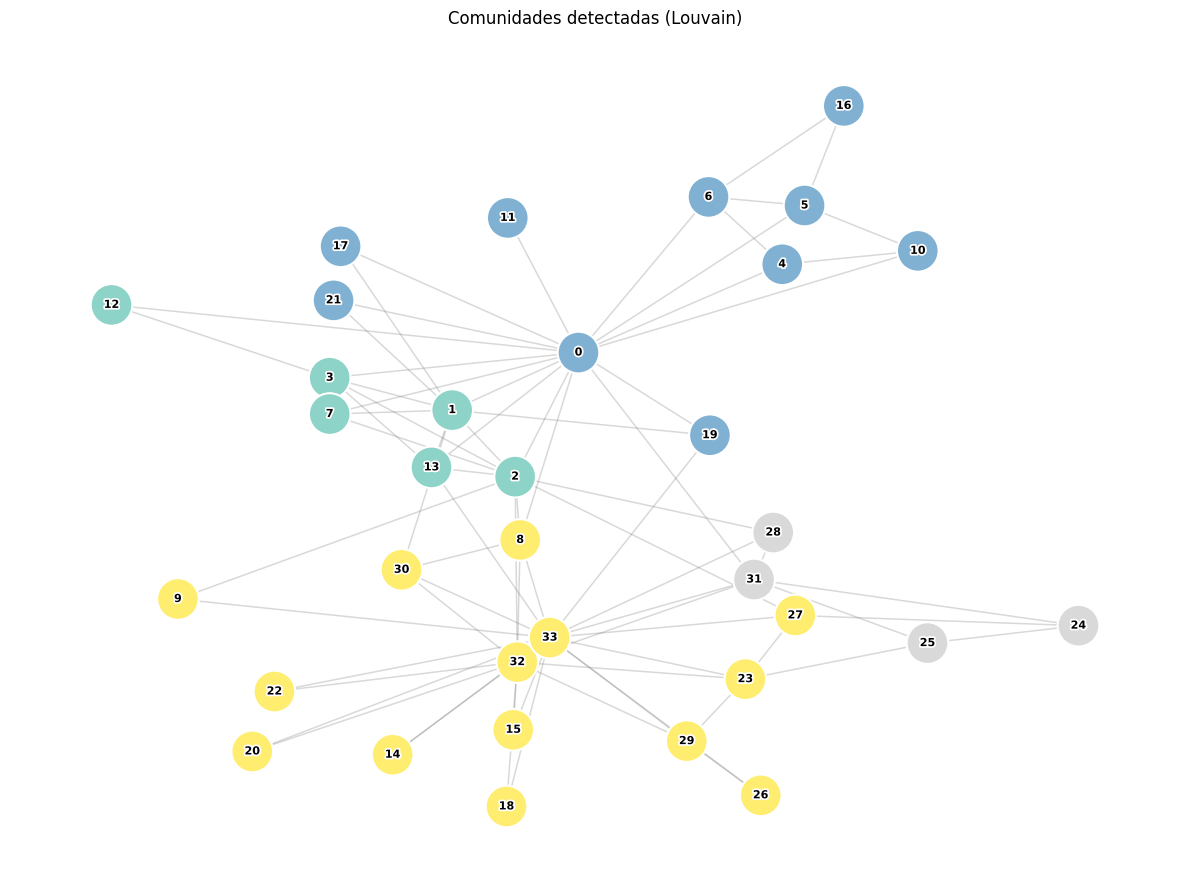

In [14]:
# Visualización de comunidades con color por grupo
nodos_ordenados = list(G.nodes())
mapa_comunidad = {}
for idx, com in enumerate(comunidades):
    for nodo in com:
        mapa_comunidad[nodo] = idx

colores = [mapa_comunidad[n] for n in nodos_ordenados]

plt.figure(figsize=(12, 9))
nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.3, width=1.1)
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=nodos_ordenados,
    node_color=colores,
    cmap=plt.cm.Set3,
    node_size=900,
    edgecolors='white',
    linewidths=1.5
)
labels = nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')
for txt in labels.values():
    txt.set_path_effects([pe.withStroke(linewidth=2.5, foreground='white')])

plt.title(f'Comunidades detectadas ({metodo})')
plt.axis('off')
plt.tight_layout()
plt.show()

## Conclusiones

- Se analizaron propiedades básicas del grafo de red social.
- Se definieron 3 criterios diferentes para influencer y se halló el top para cada uno.
- Se detectaron comunidades y se clasificaron por tamaño.